<h1>Initial Modeling Work</h1>

In [1]:
%pip install pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [36]:
##IMPORTING THE CLEANED DATA
import pandas as pd
import numpy as np

data = pd.read_csv("LA_Assault_Data_2020_Present.csv")

In [37]:
##CONVERTING TO DATETIME
data["DATE OCC"] = pd.to_datetime(data["DATE OCC"])

In [38]:
##CREATING TIME VARIABLES
data["year"] = data["DATE OCC"].dt.year
data["month"] = data["DATE OCC"].dt.month
data["day_of_week"] = data["DATE OCC"].dt.dayofweek

In [39]:
##ESTABLISHING SPATIAL GRID CELLS

##0.01 degrees ≈ ~1km
grid_size = 0.01

data["lat_grid"] = (data["LAT"] // grid_size) * grid_size
data["lon_grid"] = (data["LON"] // grid_size) * grid_size

In [40]:
##CREATING A SPATIOTEMPORAL DATASET

crime_grid = (
    data.groupby(["lat_grid","lon_grid","year","month"])
    .size()
    .reset_index(name="crime_count")
)
##each row should represent a grid-cell and a time period

In [41]:
# Create full monthly time index
all_months = pd.date_range(
    start=data["DATE OCC"].min(),
    end=data["DATE OCC"].max(),
    freq="MS"
)

# Create full grid-time combinations
grid_index = pd.MultiIndex.from_product(
    [crime_grid["lat_grid"].unique(),
     crime_grid["lon_grid"].unique(),
     all_months],
    names=["lat_grid","lon_grid","date"]
)

full_grid = pd.DataFrame(index=grid_index).reset_index()

# Extract year/month
full_grid["year"] = full_grid["date"].dt.year
full_grid["month"] = full_grid["date"].dt.month

# Merge with crime counts
crime_grid = full_grid.merge(
    crime_grid,
    on=["lat_grid","lon_grid","year","month"],
    how="left"
)

# Fill missing crime counts
crime_grid["crime_count"] = crime_grid["crime_count"].fillna(0)

In [43]:
##ADDING LAG FEATURES
crime_grid = crime_grid.sort_values(["lat_grid", "lon_grid", "date"])

crime_grid["lag_1"] = crime_grid.groupby(["lat_grid", "lon_grid"])["crime_count"].shift(1)
crime_grid["lag_3"] = crime_grid.groupby(["lat_grid", "lon_grid"])["crime_count"].shift(3)
crime_grid["lag_6"] = crime_grid.groupby(["lat_grid", "lon_grid"])["crime_count"].shift(6)

In [44]:
crime_grid

,lat_grid,lon_grid,date,year,month,crime_count,lag_1,lag_3,lag_6
1836,33.70,-118.67,2020-01-01,2020,1,0.0,NaN,NaN,NaN
1837,33.70,-118.67,2020-02-01,2020,2,0.0,0.0,NaN,NaN
1838,33.70,-118.67,2020-03-01,2020,3,0.0,0.0,NaN,NaN
1839,33.70,-118.67,2020-04-01,2020,4,0.0,0.0,0.0,NaN
1840,33.70,-118.67,2020-05-01,2020,5,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...
119443,34.33,-118.16,2022-08-01,2022,8,0.0,0.0,0.0,0.0
119444,34.33,-118.16,2022-09-01,2022,9,0.0,0.0,0.0,0.0
119445,34.33,-118.16,2022-10-01,2022,10,0.0,0.0,0.0,0.0
119446,34.33,-118.16,2022-11-01,2022,11,0.0,0.0,0.0,0.0


In [45]:
crime_grid = crime_grid.groupby(["lat_grid","lon_grid"]).filter(
    lambda x: x["crime_count"].sum() > 0
)

In [49]:
crime_grid = crime_grid.dropna(subset=["lag_1","lag_3","lag_6"])

In [50]:
crime_grid.shape

(35280, 9)

<Axes: >

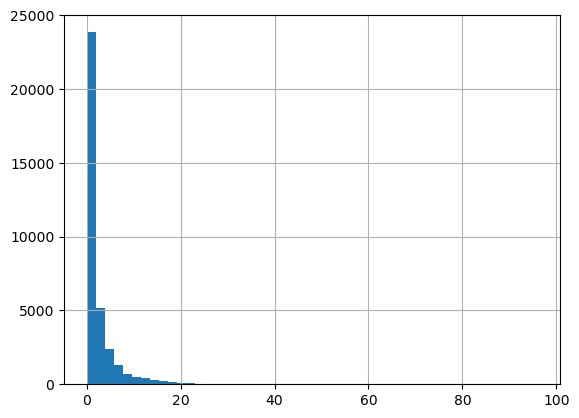

In [51]:
crime_grid["crime_count"].hist(bins=50)

<h2>Baseline Regression Model</h2>
<p>Training a linear regression model using the sklearn package. The purpose is to create a baseline model as a reference point as we build future models.</p>

In [52]:
train = crime_grid[crime_grid["year"] < 2022]
test = crime_grid[crime_grid["year"] >= 2022]

print(train.shape)
print(test.shape)

(21168, 9)
(14112, 9)


In [53]:
features = ["lat_grid", "lon_grid", "month", "lag_1", "lag_3", "lag_6"]

X_train = train[features]
y_train = train["crime_count"]

X_test = test[features]
y_test = test["crime_count"]

In [54]:
from sklearn.linear_model import LinearRegression

reg_model = LinearRegression()

reg_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [55]:
pred_reg = reg_model.predict(X_test)

In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, pred_reg)
rmse = np.sqrt(mean_squared_error(y_test, pred_reg))

print("Regression MAE:", mae)
print("Regression RMSE:", rmse)

Regression MAE: 1.0908197343812427
Regression RMSE: 2.3333593436303555


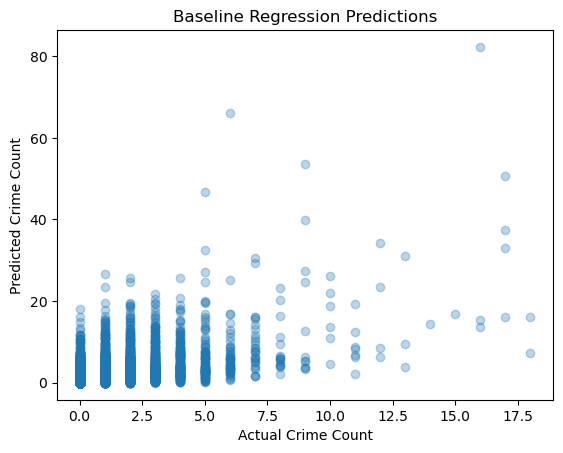

In [57]:
import matplotlib.pyplot as plt

plt.scatter(y_test, pred_reg, alpha=0.3)
plt.xlabel("Actual Crime Count")
plt.ylabel("Predicted Crime Count")
plt.title("Baseline Regression Predictions")
plt.show()

In [58]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": reg_model.coef_
})

coef_df

,Feature,Coefficient
0,lat_grid,-0.089183
1,lon_grid,0.661420
2,month,-0.007982
3,lag_1,0.386278
4,lag_3,0.300184
5,lag_6,0.266977


<h3>Writeup</h3>
<p>MAE: 1.09 <br>
RMSE: 2.33 <br>
Our MAE (mean absolute error) tells us that our model's predicted crime count for a grid cell in a given month is off by about 1 crime incident. our median crime count is around 1 which would suggest this is a reasonable baseline performance. <br>
Our RMSE (root mean squared error) is larger than our MAE because larger prediciton errors are penalized more heavily. Our value suggests that most predicitons are fairly close to the actual value, but some high-crime months create larger error. This is expected because crime distributions are highly skewed. <br>
    
Scatter Plot: <br>
A lot of our points are clustered near 0-5 crimes. We also see several outliers where the model is over predicting crime. This suggests that our regression can capture general trends but is struggling with non linear crime spikes. <br>

Coefficient Interpretation: *INSERT EQUATION* <br>
The small value for our lat_grid -0.089 suggests that the grid cells located slightly farther north may have slightly lower predicited assault counts. However, it is important to note that the magnitude is so small that it does not strongly influence predicitions. <br>
The long_grid value of 0.661 indicates that crime counts tend to increase slightly as grid cells move east-west across the city which may reflect the spatial clustering of assaults in certain urban areas. <br>

</p>